## Messages

In [1]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()


================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


/Users/siddheshdaphane/Downloads/Maza_Abhyas/AI/venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


## Chat Models

In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("GEMINI_API_KEY")

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
result = llm.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [5]:
result

AIMessage(content='That\'s a fantastic goal! Orcas are magnificent creatures to witness in the wild. When it comes to the "best" place in the US, it really boils down to two primary regions, with a strong contender and another noteworthy but less consistent option.\n\nHere are the top places to see Orcas in the US:\n\n1.  **San Juan Islands, Washington (Pacific Northwest)**\n    *   **Why it\'s the best:** This is arguably the most iconic and frequently recommended spot in the US for orca watching. The waters around the San Juan Islands are home to both the endangered Southern Resident Killer Whales (SRKW), who primarily eat salmon, and the thriving Bigg\'s (Transient) Killer Whales, who hunt marine mammals.\n    *   **Best Time:** Late spring through early fall (June to September) offers the highest chances of sightings, as the salmon runs are strong and Bigg\'s are actively hunting.\n    *   **Viewing Options:**\n        *   **Boat Tours:** Numerous reputable whale watching companies

In [6]:
result.response_metadata

{'finish_reason': 'STOP',
 'model_name': 'gemini-2.5-flash',
 'safety_ratings': [],
 'model_provider': 'google_genai'}

## Tools

In [7]:
def multiply(a: int, b: int) -> int:
    return a * b

llm_with_tools = llm.bind_tools([multiply])

In [8]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Siddhesh")])

In [9]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'c28aa1e5-01f6-4c29-ba48-9fc376ee6875',
  'type': 'tool_call'}]

## Using messages as state

In [12]:
from typing import Annotated, TypedDict
from langchain_core.messages import  AnyMessage
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [13]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    pass

In [14]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='73b82df2-4027-4af6-a6b0-4f5d0aba374c', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='d5564c7e-5a9b-4a2a-9ae6-93ebf56764f5'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='02dea25c-3e3f-4dec-9305-0dc8b76d2e52', tool_calls=[], invalid_tool_calls=[])]

## Our Graph

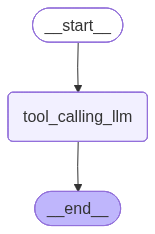

In [19]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)

builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello! I am a large language model, able to perform various tasks. How can I help you today?


In [21]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (e959d424-d438-45e8-98e1-8aebb289c647)
 Call ID: e959d424-d438-45e8-98e1-8aebb289c647
  Args:
    a: 2
    b: 3
